# Import Required Libraries

In [82]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from scipy.ndimage import gaussian_filter1d

sns.set_theme(style='dark')

In [27]:
## Reading Data
df = pd.read_excel("./Dataset/data.xlsx")

# df.head()
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


<AxesSubplot:>

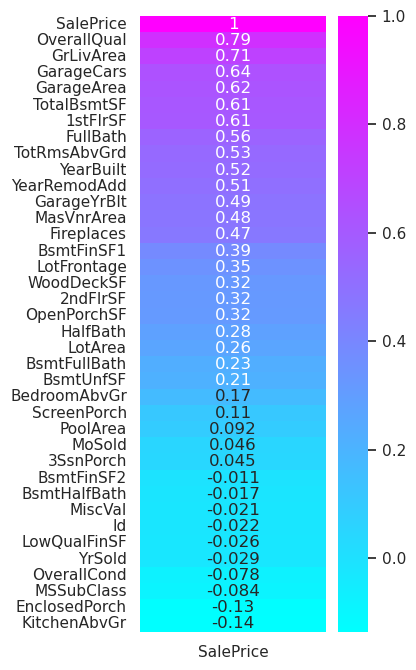

In [35]:
## Creating Heatmap
plt.figure(figsize=(3,8))

corr_data = df.corr()[['SalePrice']].sort_values('SalePrice', ascending=False)

sns.heatmap(data=corr_data, annot=True, cmap='cool')

<AxesSubplot:xlabel='OverallQual', ylabel='SalePrice'>

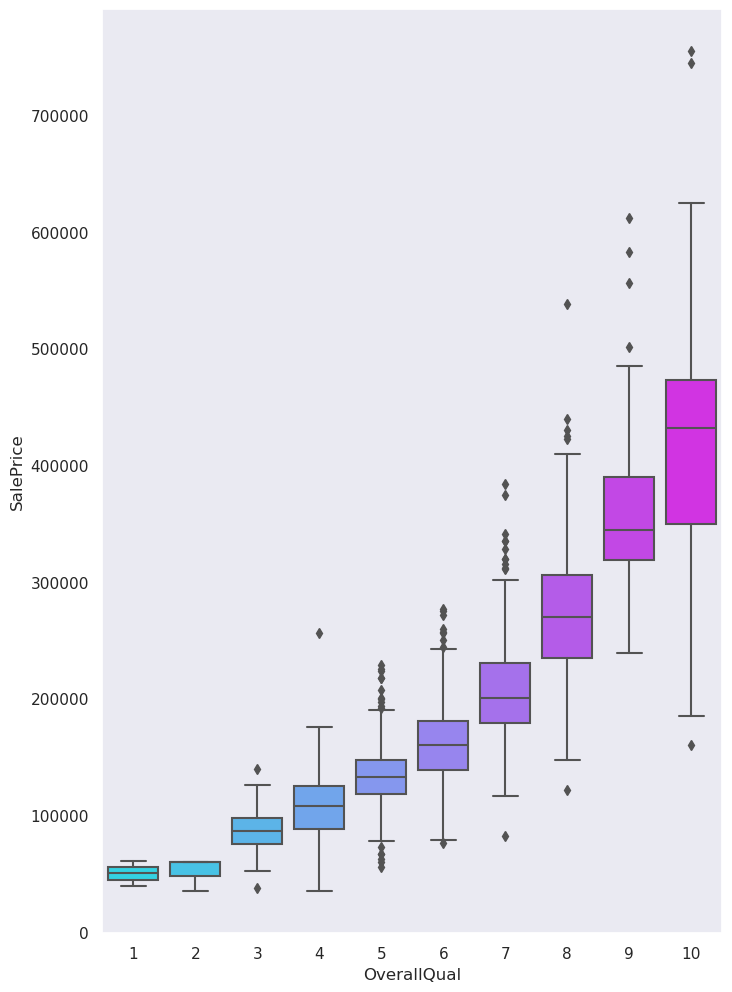

In [34]:
## Corelation of Sale Price to Overall Quality
plt.figure(figsize=(8, 12))
sns.boxplot(data=df, x="OverallQual", y="SalePrice", palette="cool")

<AxesSubplot:xlabel='KitchenAbvGr', ylabel='SalePrice'>

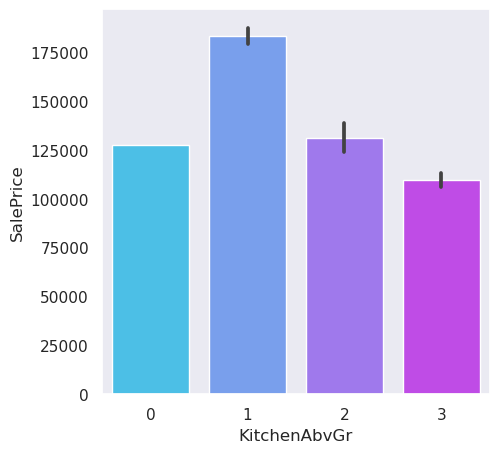

In [36]:
## Correlation of Amount of Kitchen Above Ground to Sale Price
plt.figure(figsize=(5, 5))
sns.barplot(data=df, x="KitchenAbvGr", y='SalePrice', palette='cool')
# sns.lineplot(data=df, x="KitchenAbvGr", y='SalePrice')

<AxesSubplot:xlabel='YearBuilt', ylabel='SalePrice'>

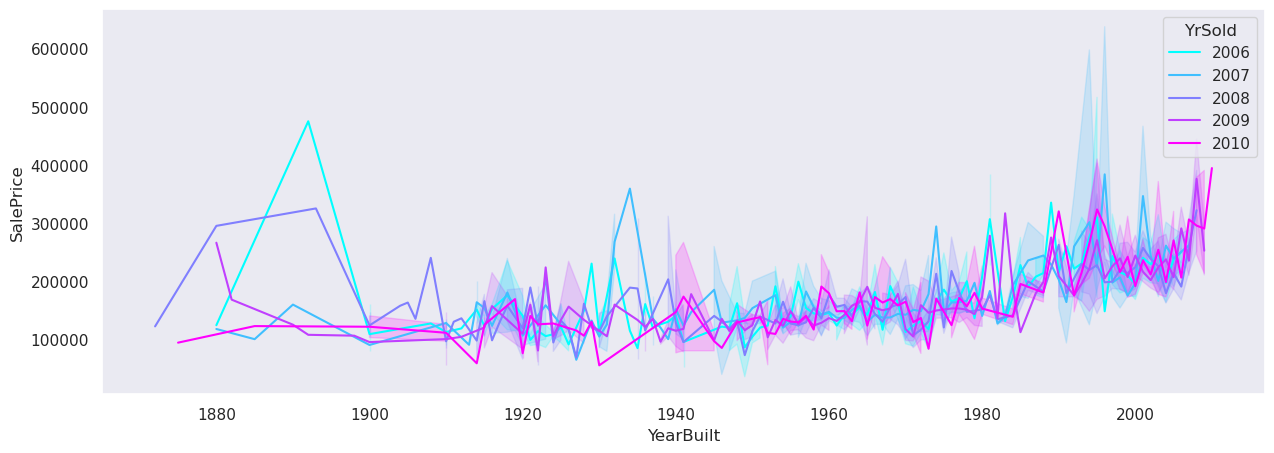

In [96]:
## Corelation of Year Built to Sale Price
from scipy import interpolate

plt.figure(figsize=(15, 5))
sns.lineplot(data=df, x='YearBuilt', y='SalePrice', palette='cool', hue='YrSold')


<AxesSubplot:xlabel='LotArea', ylabel='SalePrice'>

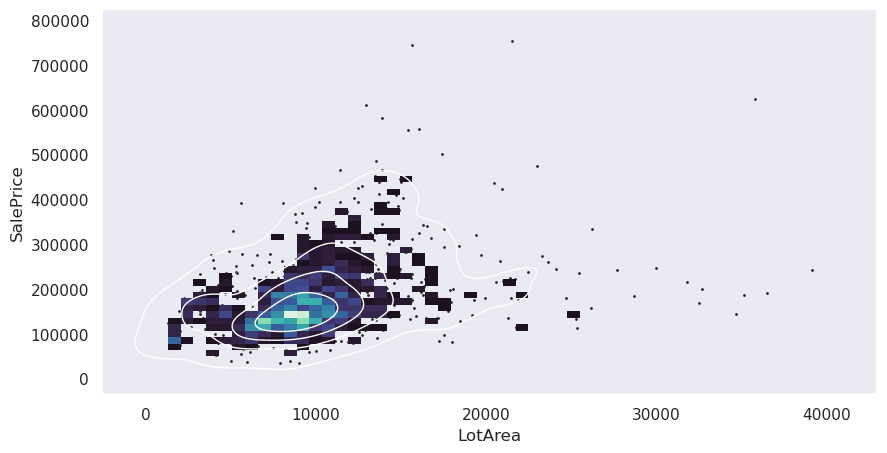

In [39]:
## Corelation of Lot Area with Sale Price

plt.figure(figsize=(10,5))

sns.kdeplot(data=df[df.LotArea < 40000], x='LotArea', y='SalePrice', levels=5, color='w', linewidths=1)
sns.scatterplot(data=df[df.LotArea < 40000], x='LotArea', y='SalePrice', s=5, color="0.15")
sns.histplot(data=df[df.LotArea < 40000], x='LotArea', y='SalePrice', bins=50, cmap='mako', pthresh=.1)

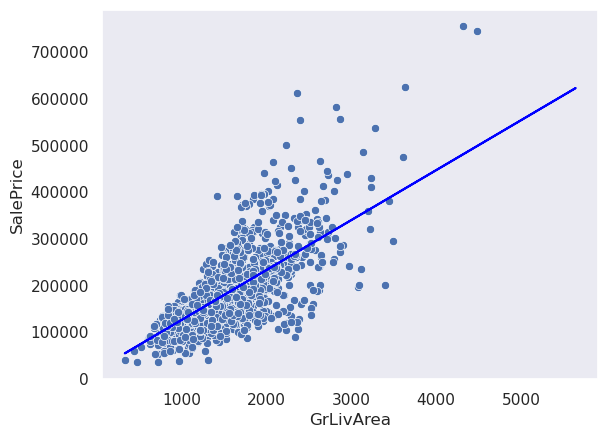

In [120]:
## Corelation of Ground Living area with Sale Price

X = df[["GrLivArea"]]
Y = df["SalePrice"]

model = LinearRegression()
model.fit(X, Y)

Y_predict = model.predict(X)

plt.plot(X, Y_predict, color='blue')

sns.scatterplot(data=df[df.GrLivArea < 4500], x="GrLivArea", y="SalePrice")

plt.show()

/tmp/ipykernel_5585/1153966561.py:13: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  sns.scatterplot(data=df[df.GarageArea > 0][df.GarageArea < 1250],  x='GarageArea', y='SalePrice', hue='GarageCars', palette='cool')


<AxesSubplot:xlabel='GarageArea', ylabel='SalePrice'>

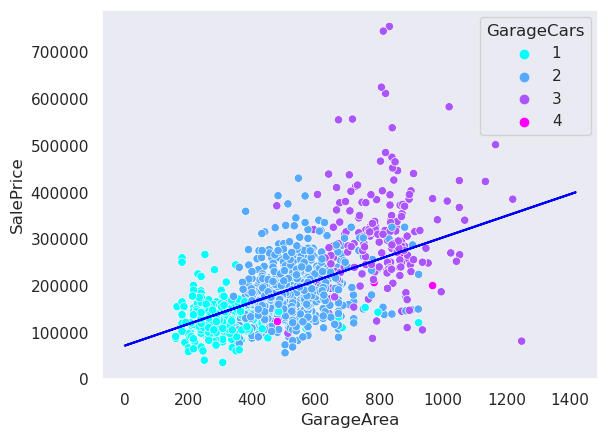

In [114]:
## Corelation of Garage Area with Sale Price

X = df[["GarageArea"]]
Y = df["SalePrice"]

model = LinearRegression()
model.fit(X, Y)

Y_predict = model.predict(X)

plt.plot(X, Y_predict, color='blue')

sns.scatterplot(data=df[df.GarageArea > 0][df.GarageArea < 1250],  x='GarageArea', y='SalePrice', hue='GarageCars', palette='cool')

<AxesSubplot:xlabel='GarageCars', ylabel='SalePrice'>

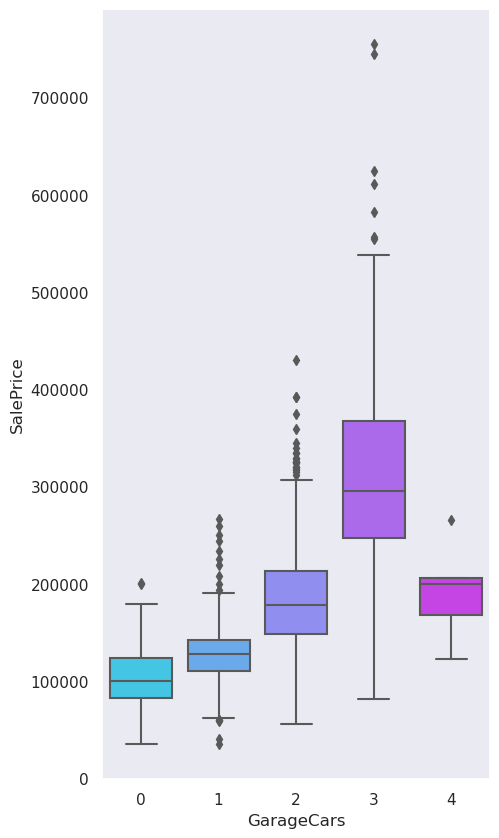

In [47]:
## Corelation of Garage Cars with Sale Price
plt.figure(figsize=(5, 10))
sns.boxplot(data=df, x='GarageCars', y='SalePrice', palette='cool')

/tmp/ipykernel_5585/1294449140.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  sns.scatterplot(data=df[df.TotalBsmtSF > 0][df.TotalBsmtSF < 4000], x='TotalBsmtSF', y='SalePrice', hue='GarageCars', palette='cool')


<AxesSubplot:xlabel='TotalBsmtSF', ylabel='SalePrice'>

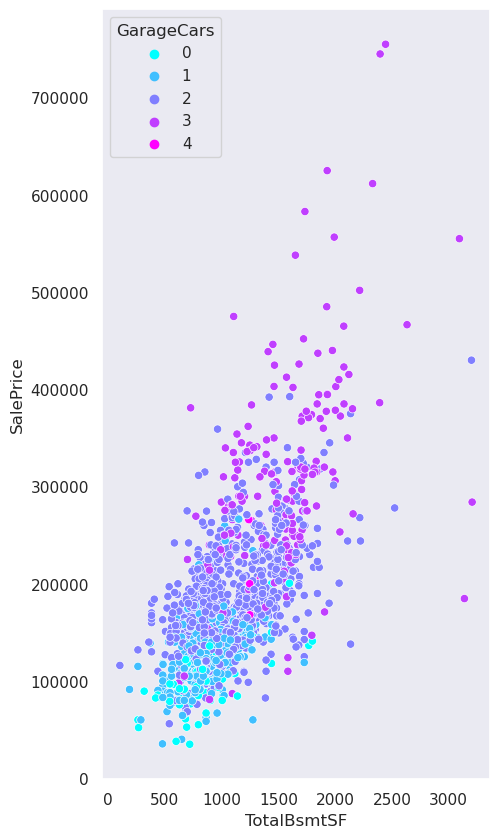

In [64]:
## Corelation of Total Basement Square Feet with Sale Price
plt.figure(figsize=(5, 10))
sns.scatterplot(data=df[df.TotalBsmtSF > 0][df.TotalBsmtSF < 4000], x='TotalBsmtSF', y='SalePrice', hue='GarageCars', palette='cool')

<AxesSubplot:xlabel='1stFlrSF', ylabel='SalePrice'>

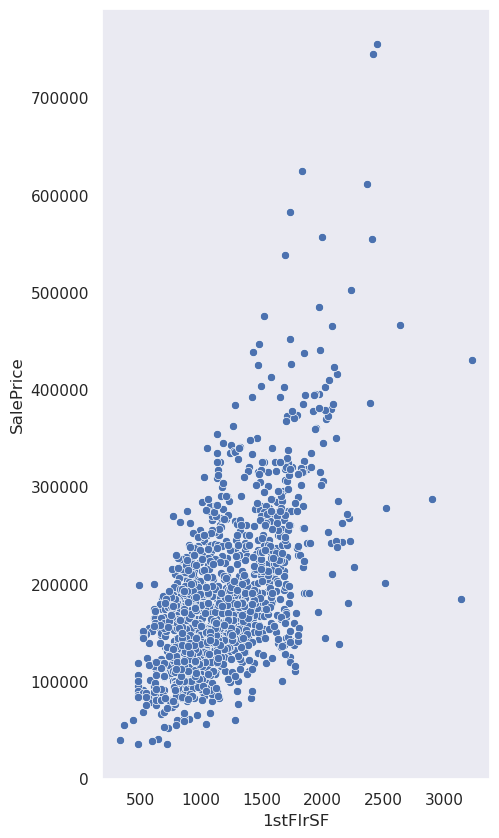

In [77]:
## Corelation of Total Basement Square Feet with Sale Price
plt.figure(figsize=(5, 10))
sns.scatterplot(data=df[df['1stFlrSF'] < 4600], x='1stFlrSF', y='SalePrice', palette='cool')

<AxesSubplot:xlabel='YrSold', ylabel='SalePrice'>

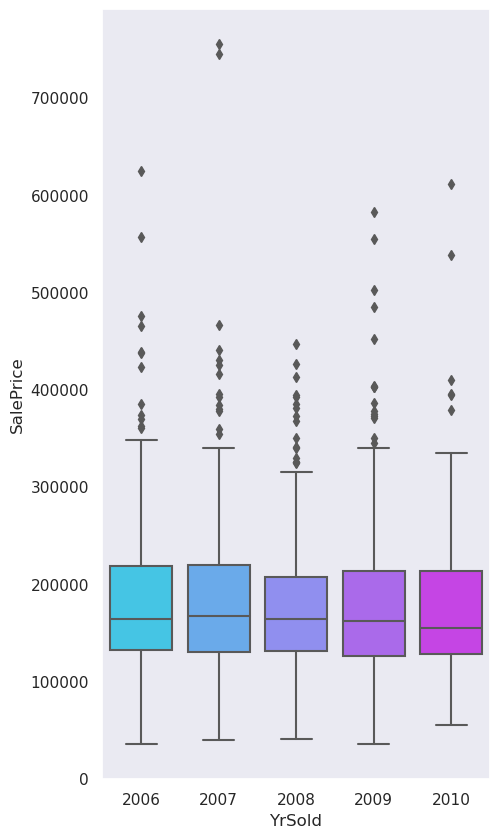

In [78]:
plt.figure(figsize=(5, 10))
sns.boxplot(data=df, x='YrSold', y='SalePrice', palette='cool')

<AxesSubplot:xlabel='OverallCond', ylabel='SalePrice'>

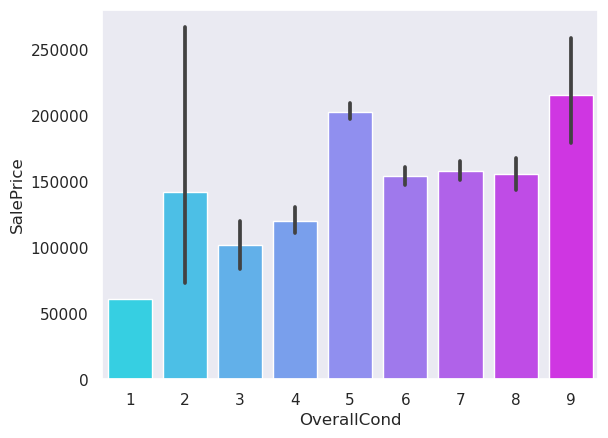

In [63]:
sns.barplot(data=df, x='OverallCond', y='SalePrice', palette='cool')